In [ ]:
# matplotlib inline

import os
import sys
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import tree

***
# Graphing

<Figure size 1200x700 with 0 Axes>

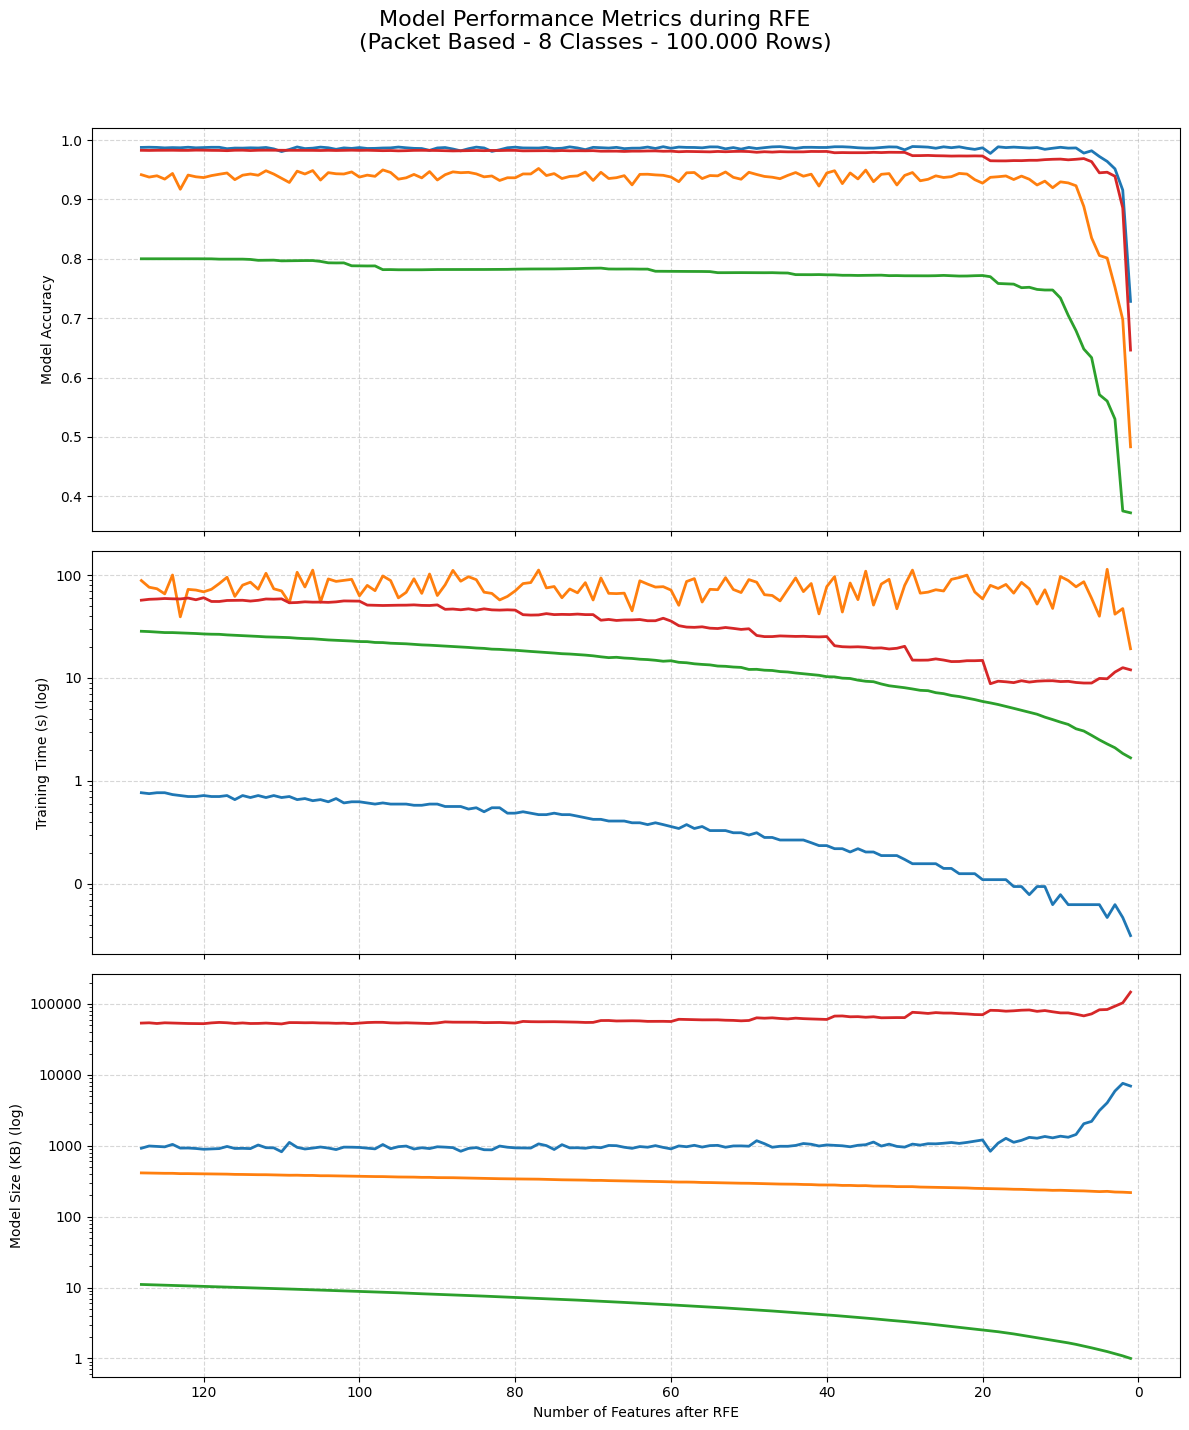

In [ ]:

import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter


# Load the results
#root_folder = "results_packet_multiclass8_n1000000"
root_folder = "UC3BCS20_main/models_2601072142" # Full run
#root_folder = "UC3BCS20_main/models_2602060734" # FNN proxy comparrison
plt.figure(figsize=(12, 7))

metrics = ['accuracy', 'size_in_KB']
titles = ['Model Accuracy', 'Training Time (s) (log)', 'Model Size (KB) (log)']

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith('_results.csv'):
            path = os.path.join(root, filename)
            df = pd.read_csv(path).sort_values(by='num_features')
            model_label = filename.split('_')[0].upper()

            # Plot each metric in its own subplot
            for i, metric in enumerate(metrics):
                axes[i].plot(df['num_features'], df[metric], 
                             marker='', label=f'{model_label}', 
                             linewidth=2)
                axes[i].set_ylabel(titles[i])
                axes[i].grid(True, linestyle='--', alpha=0.5)

# Formatting for all subplots
for ax in axes:
    ax.invert_xaxis()  # RFE standard: high features to low
    ax.legend

#axes[0].set_ylim(0.75, 1.0) # Accuracy zoom

axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

axes[2].set_yscale("log")
axes[2].yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
axes[2].set_xlabel('Number of Features after RFE')

plt.suptitle(f'Model Performance Metrics during RFE\n(Packet Based - 8 Classes - 100.000 Rows)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
#plt.savefig("results.pdf")

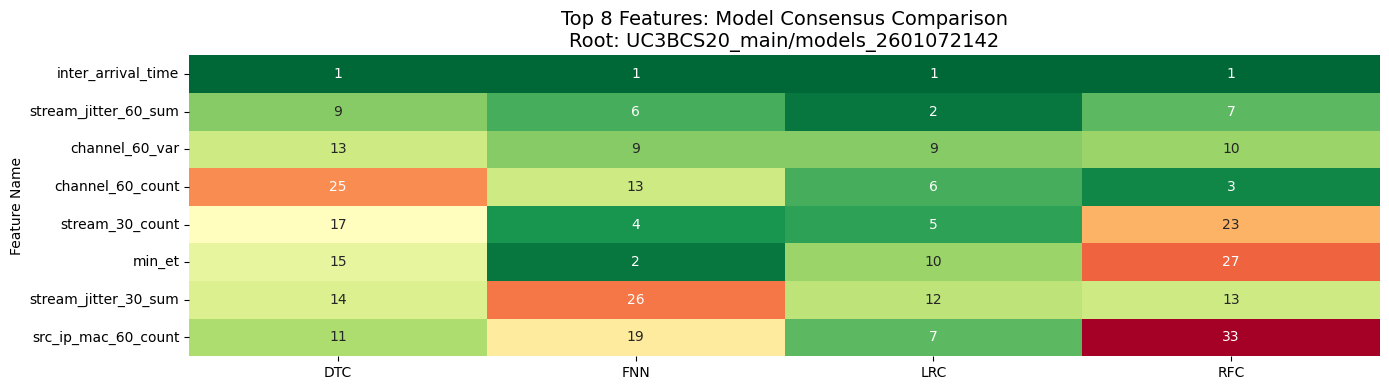

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#root_folder = "results_packet_multiclass8_n1000000"
root_folder = "UC3BCS20_main/models_2601072142"
top_n = 8

rank_data = []
if os.path.exists(root_folder):
    for root, dirs, files in os.walk(root_folder):
        for filename in files:
            if filename.endswith('features.csv'):
                path = os.path.join(root, filename)
                model_label = filename.split('_')[0].upper()
                
                df = pd.read_csv(path)
                subset = df[['feature', 'rank']].rename(columns={'rank': model_label})
                rank_data.append(subset.set_index('feature'))

master_ranks = pd.concat(rank_data, axis=1)
master_ranks['avg_rank'] = master_ranks.mean(axis=1)
master_ranks = master_ranks.sort_values('avg_rank')

df = master_ranks.head(top_n).drop(columns=['avg_rank'])
    
# Create Figure
plt.figure(figsize=(14, top_n * 0.25 + 2)) # Height changes from the numbers of rows
sns.heatmap(df, 
            annot=True, 
            fmt=".0f", 
            cbar=False, 
            cmap="RdYlGn_r")

plt.title(f'Top {top_n} Features: Model Consensus Comparison\nRoot: {root_folder}', fontsize=14)
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_21696\3363416324.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_rank', y=plot_df.index, data=plot_df, palette="viridis")


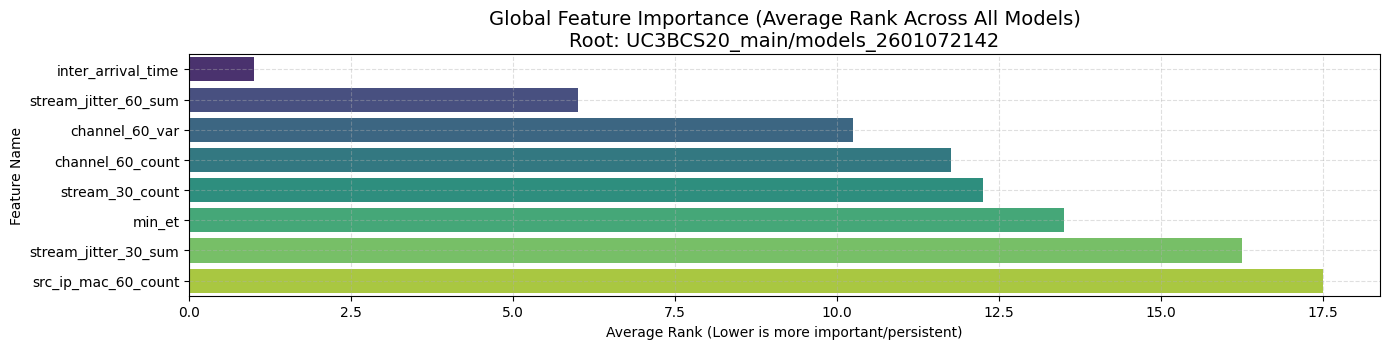

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

root_folder = "UC3BCS20_main/models_2601072142"
root_folder = "UC3BCS20_main/models_2601072142"
top_n = 8

rank_data = []
if os.path.exists(root_folder):
    for root, dirs, files in os.walk(root_folder):
        for filename in files:
            if filename.endswith('features.csv'):
                path = os.path.join(root, filename)
                model_label = filename.split('_')[0].upper()
                
                df = pd.read_csv(path)
                subset = df[['feature', 'rank']].rename(columns={'rank': model_label})
                rank_data.append(subset.set_index('feature'))

master_ranks = pd.concat(rank_data, axis=1)
master_ranks['avg_rank'] = master_ranks.mean(axis=1)
master_ranks = master_ranks.sort_values('avg_rank')

plot_df = master_ranks.head(top_n)

# Create Figure
plt.figure(figsize=(14, top_n * 0.2 + 2)) # Height based on the numbers of rows
sns.barplot(x='avg_rank', y=plot_df.index, data=plot_df, palette="viridis")

plt.title(f'Global Feature Importance (Average Rank Across All Models)\nRoot: {root_folder}', fontsize=14)
plt.xlabel('Average Rank (Lower is more important/persistent)')
plt.ylabel('Feature Name')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

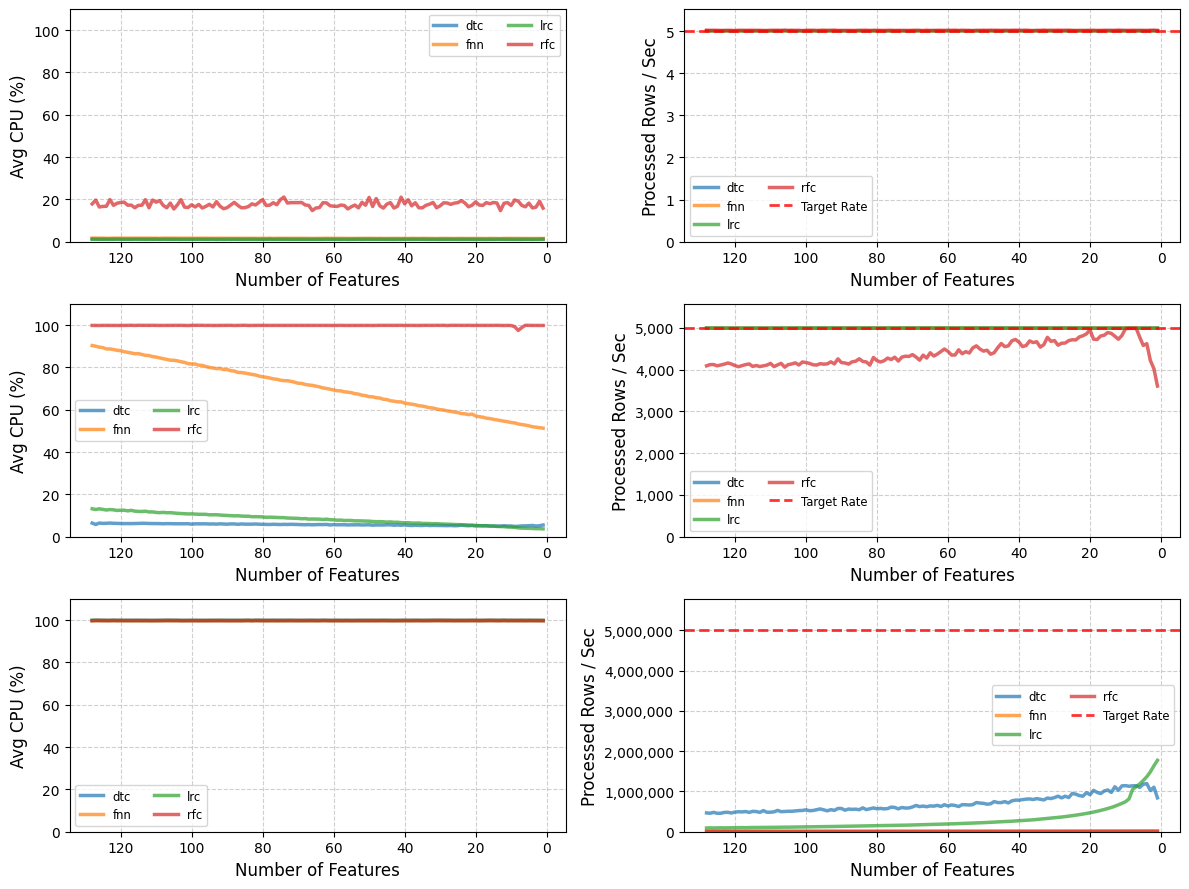

In [32]:
### ----- Graph Test Graphing -----
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  

file = "UC3BCS20_load_tester/all_models_summary.csv"
df = pd.read_csv(file)

# Extract clean Model Type (e.g., 'dtc_c8...' -> 'dtc')
df['Model_Type'] = df['Model'].apply(lambda x: x.split('_')[0])

# Get unique sorted values for iteration
rates = sorted(df['Target_Rate'].unique())
model_types = sorted(df['Model_Type'].unique())

# Create a color map: Assign a unique color to each model type
# 'tab10' is a standard high-contrast colormap
cmap = plt.get_cmap('tab10')
colors = {model: cmap(i) for i, model in enumerate(model_types)}

# Setup the plot: 1 row per target rate, 2 columns (CPU & Throughput)
# Using a slightly larger figure size for clarity
fig, axes = plt.subplots(nrows=len(rates), ncols=2, figsize=(12, 3 * len(rates)))

for i, rate in enumerate(rates):
    ax_cpu = axes[i][0]
    ax_rows = axes[i][1]
    
    # Filter data for this specific target rate
    rate_df = df[df['Target_Rate'] == rate]
    
    # --- CPU Usage ---
    for model in model_types:
        # Filter for specific model type and sort by features (descending)
        subset = rate_df[rate_df['Model_Type'] == model].sort_values(by="Num_Features", ascending=False)
        
        if not subset.empty:
            ax_cpu.plot(
                subset['Num_Features'], 
                subset['Avg_CPU'], 
                label=model, 
                color=colors[model],
                linewidth=2.5, 
                alpha=0.7,
                marker='',
                markersize=4
            )
    
    # Styling CPU Plot
    ax_cpu.set_ylabel("Avg CPU (%)", fontsize=12)
    ax_cpu.set_xlabel("Number of Features", fontsize=12)
    ax_cpu.invert_xaxis()  # High features on left, low on right
    ax_cpu.grid(True, which='major', linestyle='--', alpha=0.6)
    
    bottom, top = ax_cpu.get_ylim()
    ax_cpu.set_ylim(0, 100 * 1.1)
    
    ax_cpu.legend(loc='best', fontsize='small', ncol=2)

    # --- Rows Per Second ---
    for model in model_types:
        subset = rate_df[rate_df['Model_Type'] == model].sort_values(by="Num_Features", ascending=False)
        
        if not subset.empty:
            ax_rows.plot(
                subset['Num_Features'], 
                subset['Avg_Rows_Per_Sec'], 
                label=model, 
                color=colors[model],
                linewidth=2.5, 
                alpha=0.7,
                marker='',
                markersize=4
            )

    # Styling Throughput Plot
    ax_rows.set_ylabel("Processed Rows / Sec", fontsize=12)
    ax_rows.set_xlabel("Number of Features", fontsize=12)
    ax_rows.invert_xaxis()
    ax_rows.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    # Add target line reference
    ax_rows.axhline(y=rate, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Target Rate')
    
    ax_rows.grid(True, which='major', linestyle='--', alpha=0.6)

    bottom, top = ax_rows.get_ylim()
    ax_rows.set_ylim(0, top * 1.1)
    
    # Consolidate legend (Models + Target Line)
    handles, labels = ax_rows.get_legend_handles_labels()
    # Use a dict to remove duplicate labels if any exist
    by_label = dict(zip(labels, handles))
    ax_rows.legend(by_label.values(), by_label.keys(), loc='best', fontsize='small', ncol=2)

plt.tight_layout()
# output_filename = "performance_features_plot_matplotlib.png"
plt.savefig("load_test_results.png")
# print(f"Graph saved to: {load_test_results.png}")
plt.show()

In [81]:
import pandas as pd

# 1. Load the raw data
file = "UC3BCS20_load_tester/all_models_summary.csv"
df = pd.read_csv(file)

df['Model_Type'] = df['Model'].apply(lambda x: x.split('_')[0])

# 3. Group by Model and Target Rate
# Calculate Mean, Min, Max for both metrics
summary = df.groupby(['Model_Type', 'Target_Rate']).agg({
    'Avg_CPU': ['mean', 'max', 'min'],
    'Avg_Rows_Per_Sec': ['mean', 'max', 'min']
})

# 4. Flatten the hierarchical columns (e.g., ('Avg_CPU', 'mean') -> 'CPU_Avg')
summary.columns = [
    '_'.join(col).strip() for col in summary.columns.values
]

# 5. Rename for clarity
summary = summary.rename(columns={
    'Avg_CPU_mean': 'CPU_Avg',
    'Avg_CPU_max': 'CPU_Max',
    'Avg_CPU_min': 'CPU_Min',
    'Avg_Rows_Per_Sec_mean': 'Rows_Avg',
    'Avg_Rows_Per_Sec_max': 'Rows_Max',
    'Avg_Rows_Per_Sec_min': 'Rows_Min',
})

# 6. Formatting
# Round CPU to 2 decimals
summary[['CPU_Avg', 'CPU_Max', 'CPU_Min']] = summary[['CPU_Avg', 'CPU_Max', 'CPU_Min']].round(2)
# Round Rows to 0 decimals (integers)
summary[['Rows_Avg', 'Rows_Max', 'Rows_Min']] = summary[['Rows_Avg', 'Rows_Max', 'Rows_Min']].round(0)

summary
#summary.to_csv("load_test_results.csv")

CPU_Avg  CPU_Max  CPU_Min  Rows_Avg   Rows_Max  \
Model_Type Target_Rate                                                   
dtc        5               1.26     1.35     1.17       5.0        5.0   
           5000            5.71     6.46     4.85    4996.0     4998.0   
           5000000        99.87    99.92    99.83  696855.0  1194146.0   
fnn        5               1.60     1.71     1.50       5.0        5.0   
           5000           70.82    90.36    51.30    4996.0     4998.0   
           5000000        99.76    99.84    99.71    7501.0    10096.0   
lrc        5               1.12     1.18     1.06       5.0        5.0   
           5000            8.36    13.21     3.69    4996.0     4998.0   
           5000000        99.86    99.91    99.80  301226.0  1771133.0   
rfc        5              17.60    21.11    14.70       5.0        5.0   
           5000           99.85    99.94    97.51    4392.0     4994.0   
           5000000        99.82    99.89    99.76   11086.0    15932.0   

                        Rows_Min  
Model_Type Target_Rate            
dtc        5                 5.0  
           5000           4994.0  
           5000000      456675.0  
fnn        5                 5.0  
           5000           4994.0  
           5000000        5702.0  
lrc        5                 5.0  
           5000           4994.0  
           5000000       92142.0  
rfc        5                 5.0  
           5000           3610.0  
           5000000        9718.0

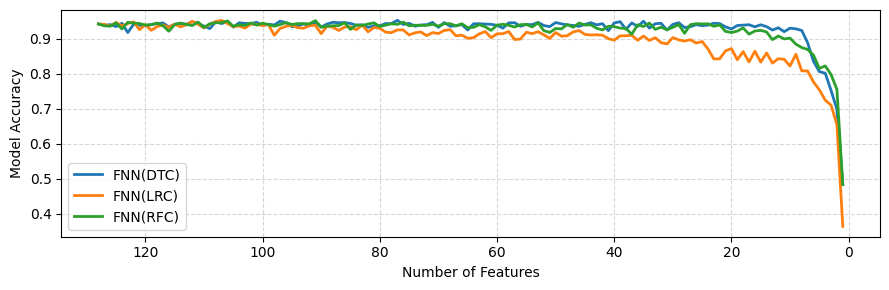

      Model  Average Accuracy
0  FNN(DTC)          0.928473
2  FNN(RFC)          0.925078
1  FNN(LRC)          0.898059


In [1]:
# --- FNN Proxy results ---

import os
import pandas as pd
import matplotlib.pyplot as plt

# Load the results
root_folder = "UC3BCS20_main/models_2602060734" 

# Create a single plot instead of subplots
plt.figure(figsize=(9, 3))
ax = plt.gca()

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith('_results.csv'):
            path = os.path.join(root, filename)
            # Sorting ensures the line connects correctly across the x-axis
            df = pd.read_csv(path).sort_values(by='num_features')
            model_label = filename.split('_')[0].upper()

            # Plotting only the accuracy column
            ax.plot(df['num_features'], df['accuracy'], 
                    marker='', label=f'{model_label}', 
                    linewidth=2)

# Formatting the single axis
ax.set_ylabel('Model Accuracy')
ax.set_xlabel('Number of Features')
ax.grid(True, linestyle='--', alpha=0.5)
ax.invert_xaxis()  # RFE standard: high features to low [cite: 864]
ax.legend(loc='best')

# plt.title('Model Accuracy Performance during RFE\n(Packet Based - 8 Classes - 100,000 Rows)', fontsize=14)
plt.tight_layout()
plt.show()
# plt.savefig("accuracy_results.pdf")

# --- Calculate and Display Average Accuracy ---
avg_accuracy_list = []

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith('_results.csv'):
            path = os.path.join(root, filename)
            df = pd.read_csv(path)
            model_label = filename.split('_')[0].upper()
            
            # mean accuracy for found model
            mean_acc = df['accuracy'].mean()
            avg_accuracy_list.append({'Model': model_label, 'Average Accuracy': mean_acc})

# Create dataframe
avg_accuracy_df = pd.DataFrame(avg_accuracy_list).sort_values(by='Average Accuracy', ascending=False)
print(avg_accuracy_df)

C:\Users\danie\AppData\Local\Temp\ipykernel_33896\1796718111.py:36: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, top)


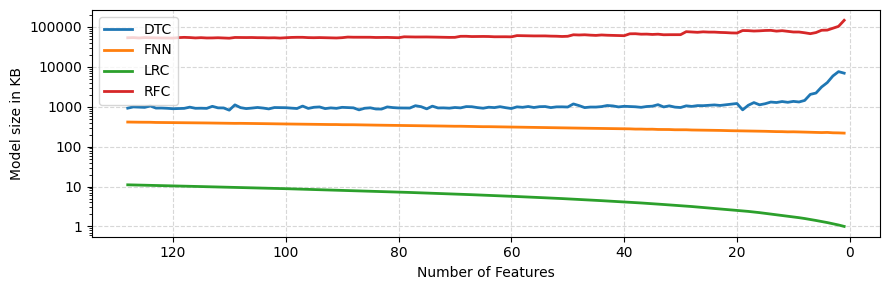

In [33]:
# --- ---

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


# Load the results
root_folder = "UC3BCS20_main/models_2601072142"

# Create a single plot instead of subplots
plt.figure(figsize=(9, 3))
ax = plt.gca()

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith('_results.csv'):
            path = os.path.join(root, filename)
            # Sorting ensures the line connects correctly across the x-axis
            df = pd.read_csv(path).sort_values(by='num_features')
            model_label = filename.split('_')[0].upper()

            # Plotting only the accuracy column
            ax.plot(df['num_features'], df['size_in_KB'], 
                    marker='', label=f'{model_label}', 
                    linewidth=2)

# Formatting the single axis
ax.set_ylabel('Model size in KB')
ax.set_xlabel('Number of Features')
ax.set_yscale("log")
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

bottom, top = ax.get_ylim()
ax.set_ylim(0, top)

ax.grid(True, linestyle='--', alpha=0.5)
ax.invert_xaxis()
ax.legend(loc='best')

plt.tight_layout()
plt.savefig("RFE_size_results.png")
plt.show()


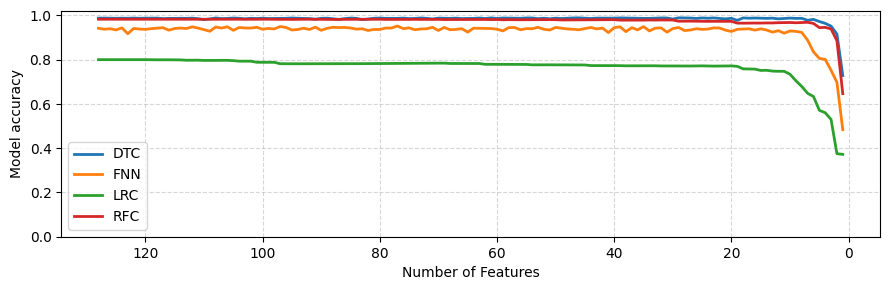

In [34]:
# --- ---

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


# Load the results
root_folder = "UC3BCS20_main/models_2601072142"

# Create a single plot instead of subplots
plt.figure(figsize=(9, 3))
ax = plt.gca()

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith('_results.csv'):
            path = os.path.join(root, filename)
            # Sorting ensures the line connects correctly across the x-axis
            df = pd.read_csv(path).sort_values(by='num_features')
            model_label = filename.split('_')[0].upper()

            # Plotting only the accuracy column
            ax.plot(df['num_features'], df['accuracy'], 
                    marker='', label=f'{model_label}', 
                    linewidth=2)

# Formatting the single axis
ax.set_ylabel('Model accuracy')
ax.set_xlabel('Number of Features')
#ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

bottom, top = ax.get_ylim()
ax.set_ylim(0, top)

ax.grid(True, linestyle='--', alpha=0.5)
ax.invert_xaxis()
ax.legend(loc='best')

plt.tight_layout()
plt.savefig("RFE_accuracy_results.png")
plt.show()


In [24]:
# --- Avg, Min and Max for models ---

import os
import pandas as pd

root_folder = "UC3BCS20_main/models_2601072142"

def summarize_model_performance(directory, min_feat, max_feat):
    summary_data = []

    for root, dirs, files in os.walk(directory):
        for filename in files:
            if filename.endswith('_results.csv'):
                model_label = filename.split('_')[0].upper()
                
                file_path = os.path.join(root, filename)
                df = pd.read_csv(file_path)

                # Filter for the specified feature range
                range = (df['num_features'] >= min_feat) & (df['num_features'] <= max_feat)
                filtered_df = df[range]

                if not filtered_df.empty:
                    summary_data.append({
                        'Model': model_label,
                        'Avg Accuracy': filtered_df['accuracy'].mean(),
                        'Max Accuracy': filtered_df['accuracy'].max(),
                        'Min Accuracy': filtered_df['accuracy'].min(),
                        'Avg Precision': filtered_df['precision'].mean(),
                        'Max Precision': filtered_df['precision'].max(),
                        'Min Precision': filtered_df['precision'].min(),
                        'Avg Recall': filtered_df['recall'].mean(),
                        'Max Recall': filtered_df['recall'].max(),
                        'Min Recall': filtered_df['recall'].min(),
                        'Avg F1-score': filtered_df['f1-score'].mean(),
                        'Max F1-score': filtered_df['f1-score'].max(),
                        'Min F1-score': filtered_df['f1-score'].min(),
                        'Avg Model Size': filtered_df['size_in_KB'].mean(),
                        'Max Model Size': filtered_df['size_in_KB'].max(),
                        'Min Model Size': filtered_df['size_in_KB'].min(),

                    })

    # Create summary 
    summary_df = pd.DataFrame(summary_data)
    
    # Sort after avg accuracy
    summary_df = summary_df.sort_values(by='Avg Accuracy', ascending=False)
    
    return summary_df

# Feature range
min_features_to_include = 128
max_features_to_include = 128

results_table = summarize_model_performance(
    root_folder, 
    min_feat=min_features_to_include, 
    max_feat=max_features_to_include
)

print(results_table.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))


Model  Avg Accuracy  Max Accuracy  Min Accuracy  Avg Precision  Max Precision  Min Precision  Avg Recall  Max Recall  Min Recall  Avg F1-score  Max F1-score  Min F1-score  Avg Model Size  Max Model Size  Min Model Size
  DTC        0.9876        0.9876        0.9876         0.9876         0.9876         0.9876      0.9876      0.9876      0.9876        0.9876        0.9876        0.9876        922.7754        922.7754        922.7754
  RFC        0.9827        0.9827        0.9827         0.9833         0.9833         0.9833      0.9827      0.9827      0.9827        0.9829        0.9829        0.9829      53722.0010      53722.0010      53722.0010
  FNN        0.9416        0.9416        0.9416         0.9450         0.9450         0.9450      0.9416      0.9416      0.9416        0.9423        0.9423        0.9423        414.2012        414.2012        414.2012
  LRC        0.8000        0.8000        0.8000         0.8216         0.8216         0.8216      0.8000      0.8000      0.